In [2]:
import sys
!{sys.executable} -m pip install tonic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 3.9 MB/s  0:00:04m 3.9 MB/s eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 3.6 MB/s  0:00:003.7 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 3.8 MB/s  0:00:003.4 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 3.8 MB/s  0:00:09 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 3.8 MB/s  0:00:023.8 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 3.8 MB/s  0:00:05 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 3.9 MB/s  0:00:00m 4.1 MB/s eta 0:00:01
  Created wheel f

In [4]:
import tonic
import tonic.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# Download N-MNIST dataset (will download automatically the first time)
dataset = tonic.datasets.NMNIST(save_to='./data', train=True)

# Grab one sample
events, label = dataset[0]

print(f"This sample is the digit: {label}")
print(f"Number of events: {len(events)}")
print(f"First 5 events: {events[:5]}")

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1082)>

In [5]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import tonic
import numpy as np
import matplotlib.pyplot as plt

dataset = tonic.datasets.NMNIST(save_to='./data', train=True)
events, label = dataset[0]

print(f"This sample is the digit: {label}")
print(f"Number of events: {len(events)}")
print(f"First 5 events: {events[:5]}")

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1082)>

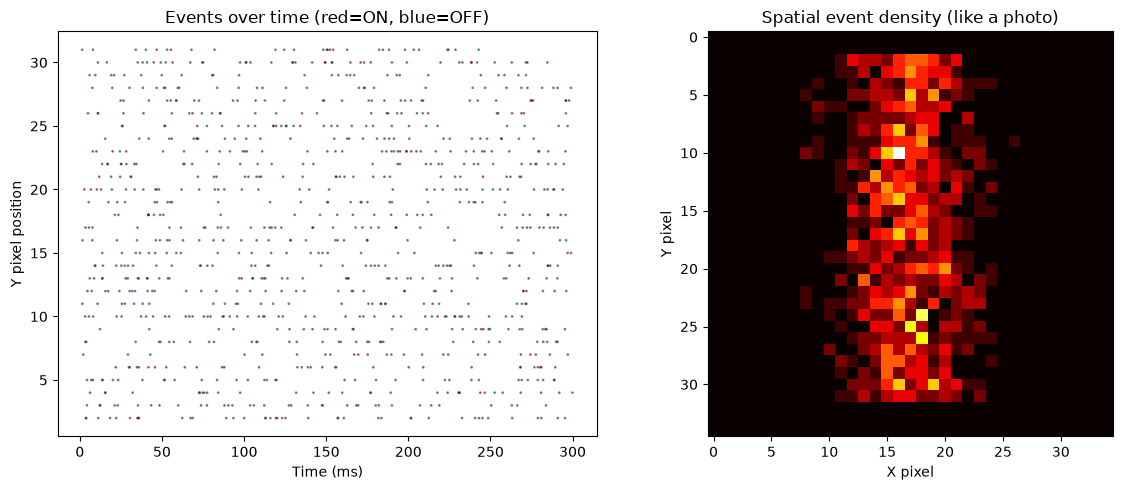

Total events: 1000
Duration: 299.9 ms
Sample events (t, x, y, polarity):
  t=1.39ms  x=17  y=31  pol=1
  t=1.52ms  x=12  y=11  pol=0
  t=1.66ms  x=18  y=16  pol=1
  t=2.09ms  x=18  y=7  pol=1
  t=2.76ms  x=18  y=20  pol=0


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from brian2 import *

# Simulate what N-MNIST event data looks like
# Each event has: x position, y position, timestamp, polarity
np.random.seed(42)

def generate_digit_events(n_events=1000, duration_ms=300):
    """
    Generate synthetic events that mimic a DVS camera 
    recording a handwritten digit
    """
    # Simulate a digit shape (like the number 1)
    # concentrated events along a vertical line
    t = np.sort(np.random.uniform(0, duration_ms, n_events))
    
    # x events clustered around centre (like a vertical stroke)
    x = np.random.normal(17, 3, n_events).clip(0, 34).astype(int)
    
    # y events spread vertically
    y = np.random.uniform(2, 32, n_events).astype(int)
    
    # polarity: +1 (bright edge) or -1 (dark edge)
    polarity = np.random.choice([0, 1], n_events)
    
    return t, x, y, polarity

t, x, y, pol = generate_digit_events()

# Visualise the events
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: events in time (like a raster plot but for pixels)
axes[0].scatter(t, y, c=pol, cmap='RdBu', s=1, alpha=0.5)
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Y pixel position')
axes[0].set_title('Events over time (red=ON, blue=OFF)')

# Plot 2: spatial distribution (what the digit looks like)
event_frame = np.zeros((35, 35))
for i in range(len(t)):
    event_frame[y[i], x[i]] += 1

axes[1].imshow(event_frame, cmap='hot')
axes[1].set_title('Spatial event density (like a photo)')
axes[1].set_xlabel('X pixel')
axes[1].set_ylabel('Y pixel')

plt.tight_layout()
plt.show()

print(f"Total events: {len(t)}")
print(f"Duration: {t[-1]:.1f} ms")
print(f"Sample events (t, x, y, polarity):")
for i in range(5):
    print(f"  t={t[i]:.2f}ms  x={x[i]}  y={y[i]}  pol={pol[i]}")

WARNING    Removing unsupported flag '-march=native' from compiler flags. [brian2.codegen.cpp_prefs]


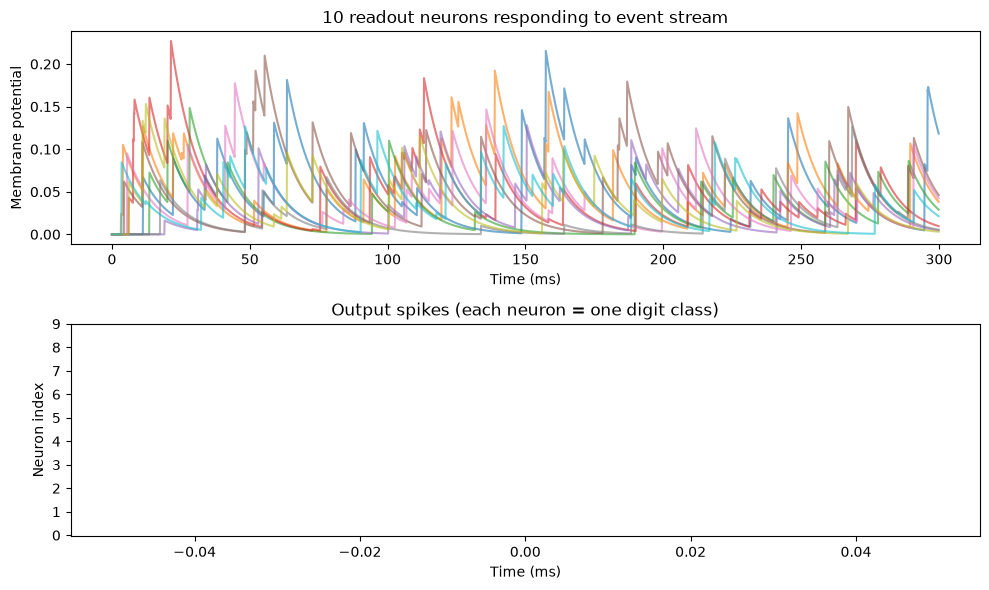

Total output spikes: 0
Spikes per neuron: [0 0 0 0 0 0 0 0 0 0]


In [7]:
# Convert events into spike trains for Brian2
start_scope()

# Time resolution for binning events
dt_ms = 5  # 5ms time bins

# Create spike times for each pixel that fired
n_pixels = 35 * 35  # 35x35 pixel grid
pixel_indices = y * 35 + x  # convert 2D pixel to 1D index

# Only use ON events (polarity = 1)
on_mask = pol == 1
on_times = t[on_mask] * ms
on_pixels = pixel_indices[on_mask]

# Create a SpikeGeneratorGroup - feeds real event data into Brian2
spike_input = SpikeGeneratorGroup(n_pixels, on_pixels, on_times)

# Small readout layer - 10 neurons (one per digit class)
tau = 10*ms
readout = NeuronGroup(10, 'dv/dt = -v/tau : 1',
                      threshold='v>0.5', reset='v=0',
                      method='exact')

# Connect input pixels to readout neurons randomly
S = Synapses(spike_input, readout, 'w : 1', on_pre='v_post += w')
S.connect(p=0.05)
S.w = 'rand() * 0.1'

# Record output spikes
spike_mon = SpikeMonitor(readout)
voltage_mon = StateMonitor(readout, 'v', record=True)

run(300*ms)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

ax1.plot(voltage_mon.t/ms, voltage_mon.v.T, alpha=0.6)
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Membrane potential')
ax1.set_title('10 readout neurons responding to event stream')

ax2.plot(spike_mon.t/ms, spike_mon.i, '|k', ms=10)
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Neuron index')
ax2.set_title('Output spikes (each neuron = one digit class)')
ax2.set_yticks(range(10))

plt.tight_layout()
plt.show()

print(f"Total output spikes: {len(spike_mon.t)}")
print(f"Spikes per neuron: {np.bincount(spike_mon.i, minlength=10)}")

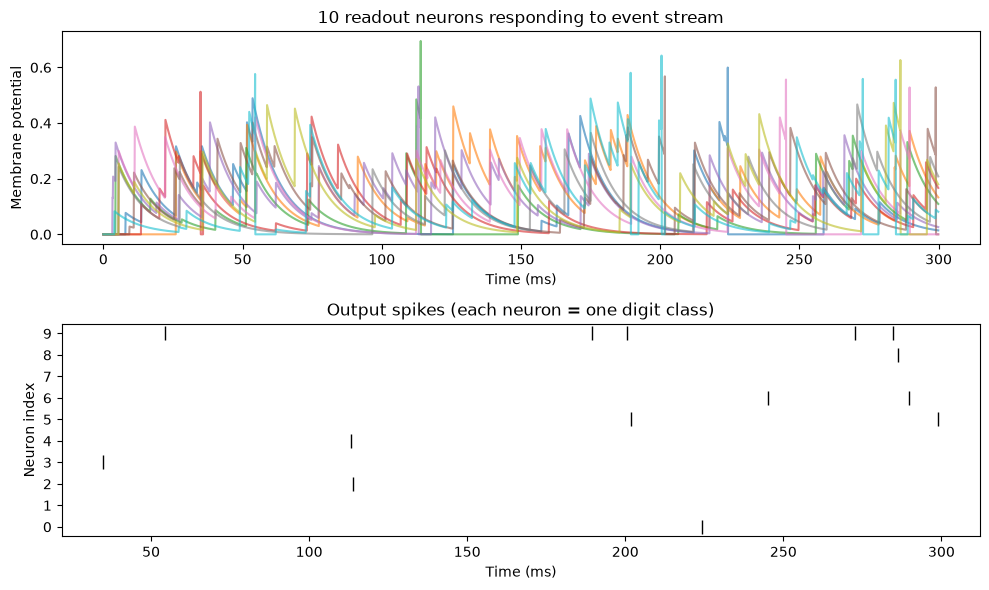

Total output spikes: 14
Spikes per neuron: [1 0 1 1 1 2 2 0 1 5]


In [8]:
start_scope()

n_pixels = 35 * 35
pixel_indices = y * 35 + x
on_mask = pol == 1
on_times = t[on_mask] * ms
on_pixels = pixel_indices[on_mask]

spike_input = SpikeGeneratorGroup(n_pixels, on_pixels, on_times)

tau = 10*ms
readout = NeuronGroup(10, 'dv/dt = -v/tau : 1',
                      threshold='v>0.5', reset='v=0',
                      method='exact')

S = Synapses(spike_input, readout, 'w : 1', on_pre='v_post += w')
S.connect(p=0.05)
S.w = 'rand() * 0.3'  # increased from 0.1 to 0.3

spike_mon = SpikeMonitor(readout)
voltage_mon = StateMonitor(readout, 'v', record=True)

run(300*ms)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

ax1.plot(voltage_mon.t/ms, voltage_mon.v.T, alpha=0.6)
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Membrane potential')
ax1.set_title('10 readout neurons responding to event stream')

ax2.plot(spike_mon.t/ms, spike_mon.i, '|k', ms=10)
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Neuron index')
ax2.set_title('Output spikes (each neuron = one digit class)')
ax2.set_yticks(range(10))

plt.tight_layout()
plt.show()

print(f"Total output spikes: {len(spike_mon.t)}")
print(f"Spikes per neuron: {np.bincount(spike_mon.i, minlength=10)}")